<a href="https://colab.research.google.com/github/harshitneverdebugs/DeepLearning/blob/master/YOLOv8n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###XYZ

In [ ]:
pip install ultralytics #Installing the Ultralytics YOLO library

In [ ]:
from ultralytics import YOLO #importing YOLO from Ultralytics
import cv2#importing OpenCV library

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def detect_humans_in_video(video_path, output_path): # function for detecting humans

    #Loading the YOLOv8 model
    model = YOLO("yolov8n.pt")  # loading the YOLOv8 Nano model

    #Opening the video file
    cap = cv2.VideoCapture(video_path)  # initializing video capture from the specified video file
    if not cap.isOpened():  # check if the video is successfully opened
        print(f"Error: Unable to open video file {video_path}")
        return

    #Getting the video properties
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # width of the video frame
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # height of the video frame
    fps = cap.get(cv2.CAP_PROP_FPS)  # frames per second of the video
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # defining the codec for the video (codec stands for coder-decoder)

    #Creating a Video writer for saving the output video
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    try:
        while cap.isOpened():  # Loop through the video as long as the video is opened
            ret, frame = cap.read()  # Reading the next frame of the video
            if not ret:  # Break the loop if the next video frames are not present, video has ended
                break

            # Perform the person detection
            results = model(frame)

            # Annotate the frame with human detections
            annotated_frame = frame.copy()
            for result in results:
                for box in result.boxes:
                    # Extract the class ID and confidence score
                    class_id = int(box.cls[0])  # Class ID of the object
                    confidence = box.conf[0]  # Confidence score

                    # Only process detections with confidence greater than 50%
                    if confidence > 0.5:  # Only consider detections with more than 50% confidence
                        # Check if the detected object is a person (class ID 0 in COCO dataset)
                        if class_id == 0:  # Class 0 corresponds to "person"
                            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Extract the bounding box coordinates (x1, y1, x2, y2)
                            cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draw a rectangle around the detected person
                            label = f"{confidence:.2f}"  # Adding the confidence score as a label
                            cv2.putText(annotated_frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

            # Write the annotated frame to the output video
            out.write(annotated_frame)

    except Exception as e: # Print an error message if an exception occurs during processing
        print(f"An error occurred: {e}")
    finally:
        # Release resources including the path of the output video
        cap.release()
        out.release()
        print(f"Processed video saved at {output_path}")

In [ ]:
#prediction made on vid2
video_path = "/content/drive/MyDrive/vid2.mp4"#path of input video
output_path = "output_video2.mp4"#outpput video path

detect_humans_in_video(video_path, output_path)#calling the above function with the input and output paths respectively

100%|██████████| 6.25M/6.25M [00:00<00:00, 107MB/s]



0: 384x640 8 persons, 1 chair, 105.5ms
Speed: 19.3ms preprocess, 105.5ms inference, 817.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 chair, 9.7ms
Speed: 3.4ms preprocess, 9.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 handbag, 1 chair, 8.8ms
Speed: 2.2ms preprocess, 8.8ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 2 handbags, 1 chair, 8.6ms
Speed: 2.0ms preprocess, 8.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 2 handbags, 1 chair, 9.9ms
Speed: 3.6ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 7 persons, 1 handbag, 1 chair, 10.3ms
Speed: 2.7ms preprocess, 10.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 1 chair, 8.9ms
Speed: 2.7ms preprocess, 8.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384

In [ ]:
#prediction made on vid1
video_path = "/content/drive/MyDrive/vid1.mp4"
output_path = "output_video1.mp4"

detect_humans_in_video(video_path, output_path)


0: 384x640 11 persons, 2 handbags, 7.1ms
Speed: 2.1ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 6.9ms
Speed: 2.5ms preprocess, 6.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 8 persons, 2 handbags, 6.5ms
Speed: 2.6ms preprocess, 6.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 9 persons, 3 handbags, 6.4ms
Speed: 2.4ms preprocess, 6.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 10 persons, 1 handbag, 9.5ms
Speed: 2.7ms preprocess, 9.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 1 handbag, 6.9ms
Speed: 2.7ms preprocess, 6.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 11 persons, 6.6ms
Speed: 2.2ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 persons, 6.7ms
Speed: 2.2ms preprocess, 6.7ms i

In [ ]:
#prediction made on vid3
video_path = "/content/drive/MyDrive/vid3.mp4"
output_path = "output_video3.mp4"

detect_humans_in_video(video_path, output_path)


0: 384x640 28 persons, 1 bicycle, 1 car, 2 motorcycles, 13.6ms
Speed: 4.5ms preprocess, 13.6ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 25 persons, 1 bicycle, 1 car, 2 motorcycles, 29.8ms
Speed: 2.7ms preprocess, 29.8ms inference, 4.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 26 persons, 1 bicycle, 1 car, 2 motorcycles, 9.3ms
Speed: 2.9ms preprocess, 9.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 23 persons, 1 bicycle, 1 car, 2 motorcycles, 13.9ms
Speed: 4.3ms preprocess, 13.9ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 25 persons, 1 bicycle, 1 car, 2 motorcycles, 10.3ms
Speed: 2.7ms preprocess, 10.3ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 23 persons, 1 bicycle, 1 car, 2 motorcycles, 17.6ms
Speed: 2.7ms preprocess, 17.6ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 23 persons, 1 bicycle, 1

In [ ]:
#prediction made on vid6
video_path = "/content/drive/MyDrive/vid6.mp4"
output_path = "output_video6.mp4"

detect_humans_in_video(video_path, output_path)


0: 384x640 18 persons, 1 umbrella, 6.9ms
Speed: 1.8ms preprocess, 6.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 persons, 6.6ms
Speed: 2.8ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 1 umbrella, 6.8ms
Speed: 2.7ms preprocess, 6.8ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 persons, 1 umbrella, 6.6ms
Speed: 2.7ms preprocess, 6.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 1 umbrella, 6.5ms
Speed: 2.3ms preprocess, 6.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 persons, 1 umbrella, 6.6ms
Speed: 2.1ms preprocess, 6.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 12 persons, 1 horse, 1 umbrella, 7.1ms
Speed: 2.7ms preprocess, 7.1ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 persons, 1 horse, 1 um

From the output video where the detection is made, it is clearly visible that our YOLOv8 model is good in detecting persons which are moving towards center of the video frame, but when the person is located in the corners of the frame are not detected or not detected in the accurate way.

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="gdXIKP3144x9M45COAkh")
project = rf.workspace("dave-r7nyf").project("test_detection_person")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Test_Detection_Person-1 in yolov8:: 100%|██████████| 2836/2836 [00:00<00:00, 3810.16it/s]


In [ ]:
print("Dataset location:", dataset.location)

# Step 6: Check the contents of the downloaded dataset
import os

# List files in the downloaded dataset directory
dataset_path = dataset.location  # The path Roboflow gives
files_in_dataset = os.listdir(dataset_path)
print("Files in dataset:", files_in_dataset)

# Now, let's check the contents of 'train', 'valid', 'test' folders
train_dir = os.path.join(dataset_path, 'train')
valid_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(dataset_path, 'test')

print("Train folder contents:", os.listdir(train_dir))
print("Valid folder contents:", os.listdir(valid_dir))
print("Test folder contents:", os.listdir(test_dir))

Dataset location: /content/Test_Detection_Person-1
Files in dataset: ['README.roboflow.txt', 'README.dataset.txt', 'test', 'train', 'data.yaml', 'valid']
Train folder contents: ['labels', 'images']
Valid folder contents: ['labels', 'images']
Test folder contents: ['labels', 'images']


In [ ]:
# Import the necessary package for YOLOv8
from ultralytics import YOLO

# Initialize YOLOv8 model (using a pre-trained model like yolov8n)
model = YOLO('yolov8n.pt')  # You can choose a different model (e.g., yolov8s.pt, yolov8m.pt)

# Train the model using the provided data.yaml file
model.train(data='/content/Test_Detection_Person-1/data.yaml', epochs=50, imgsz=640)

100%|██████████| 6.25M/6.25M [00:00<00:00, 96.5MB/s]


Ultralytics 8.3.44 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Test_Detection_Person-1/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tru

100%|██████████| 755k/755k [00:00<00:00, 20.0MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /content/Test_Detection_Person-1/train/labels... 991 images, 49 backgrounds, 0 corrupt: 100%|██████████| 991/991 [00:00<00:00, 1453.94it/s]

...

A new version of Albumentations is available: 1.4.21 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
val: Scanning /content/Test_Detection_Person-1/valid/labels... 280 images, 6 backgrounds, 0 corrupt: 100%|██████████| 280/280 [00:00<00:00, 1637.48it/s]

val: New cache created: /content/Test_Detection_Person-1/valid/labels.cache


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50         0G      1.712      2.848      1.439        105        640:  18%|█▊        | 11/62 [02:55<13:35, 15.99s/it]


KeyboardInterrupt: 

In [ ]:
best_model_path = 'runs/train/exp/weights/best.pt'
model.export(format='onnx')

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.00GHz)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 308.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 349.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.5/291.5 MB 228.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 181.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 273.1 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 21.8s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updat

'runs/detect/train/weights/best.onnx'

In [ ]:
results = model.val(data='/content/Test_Detection_Person-1/data.yaml')
print(results)

Ultralytics 8.3.43 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Model summary (fused): 168 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/Test_Detection_Person-1/valid/labels.cache... 280 images, 6 backgrounds, 0 corrupt: 100%|██████████| 280/280 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:08<00:00,  2.14it/s]


                   all        280       2207      0.735      0.603      0.647      0.342
Speed: 0.5ms preprocess, 6.2ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to runs/detect/train2
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc379919210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033

In [ ]:
results = model.predict('/content/drive/MyDrive/vid3.mp4')



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1500) /content/drive/MyDrive/vid3.mp4: 384x640 44 persons, 60.3ms
video 1/1 (frame 2/1500) /content/drive/MyDrive/vid3.mp4: 384x640 44 persons, 11.5ms
video 1/1 (frame 3/1500) /content/drive/MyDrive/vid3.mp4: 384x640 46 persons, 10.9ms
video 1/1 (frame 4/1500) /content/drive/MyDrive/vid3.mp4: 384x640 47 persons, 20.0ms
video 1/1 (frame 5/1500) /content/drive/MyDrive/vid3.mp4: 384x640 47 persons, 15.1ms
video 1/1 (frame 6/1500) /conte

In [ ]:
import cv2
import os

def visualize_predictions(video_path, results):
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Ensure video is opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Create a video writer to save the output
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Output path in Google Drive
    output_path = '/content/drive/MyDrive/output_annotated_video03.mp4'

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Use H.264 codec for better compatibility
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path,
                          fourcc,
                          fps,
                          (width, height))

    # Validate output video writer
    if not out.isOpened():
        print("Error: Could not create video writer")
        cap.release()
        return None

    # Frame index
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Safely get predictions for this frame
        if frame_idx < len(results):
            frame_result = results[frame_idx]

            # Check if the result has a .boxes attribute (common in Ultralytics models)
            if hasattr(frame_result, 'boxes'):
                # Iterate through detected boxes
                for box in frame_result.boxes:
                    # Get bounding box coordinates
                    xyxy = box.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, xyxy)

                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Write the frame
            out.write(frame)

        frame_idx += 1

    # Release resources
    cap.release()
    out.release()

    print(f"Video saved as '{output_path}'")
    return output_path

# Call the function with your video path and predictions
output_video_path = visualize_predictions('/content/drive/MyDrive/vid3.mp4', results)

Video saved as '/content/drive/MyDrive/output_annotated_video03.mp4'


In [ ]:
results = model.predict('/content/drive/MyDrive/vid6.mp4')



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/429) /content/drive/MyDrive/vid6.mp4: 384x640 18 persons, 9.9ms
video 1/1 (frame 2/429) /content/drive/MyDrive/vid6.mp4: 384x640 20 persons, 8.6ms
video 1/1 (frame 3/429) /content/drive/MyDrive/vid6.mp4: 384x640 17 persons, 9.6ms
video 1/1 (frame 4/429) /content/drive/MyDrive/vid6.mp4: 384x640 17 persons, 10.7ms
video 1/1 (frame 5/429) /content/drive/MyDrive/vid6.mp4: 384x640 16 persons, 6.4ms
video 1/1 (frame 6/429) /content/drive/M

In [ ]:
import cv2
import os

def visualize_predictions(video_path, results):
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Ensure video is opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Create a video writer to save the output
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Output path in Google Drive
    output_path = '/content/drive/MyDrive/output_annotated_video06.mp4'

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Use H.264 codec for better compatibility
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path,
                          fourcc,
                          fps,
                          (width, height))

    # Validate output video writer
    if not out.isOpened():
        print("Error: Could not create video writer")
        cap.release()
        return None

    # Frame index
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Safely get predictions for this frame
        if frame_idx < len(results):
            frame_result = results[frame_idx]

            # Check if the result has a .boxes attribute (common in Ultralytics models)
            if hasattr(frame_result, 'boxes'):
                # Iterate through detected boxes
                for box in frame_result.boxes:
                    # Get bounding box coordinates
                    xyxy = box.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, xyxy)

                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Write the frame
            out.write(frame)

        frame_idx += 1

    # Release resources
    cap.release()
    out.release()

    print(f"Video saved as '{output_path}'")
    return output_path

# Call the function with your video path and predictions
output_video_path = visualize_predictions('/content/drive/MyDrive/vid6.mp4', results)

Video saved as '/content/drive/MyDrive/output_annotated_video06.mp4'


In [ ]:
results = model.predict('/content/drive/MyDrive/vid1.mp4')



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/600) /content/drive/MyDrive/vid1.mp4: 384x640 6 persons, 8.0ms
video 1/1 (frame 2/600) /content/drive/MyDrive/vid1.mp4: 384x640 6 persons, 8.3ms
video 1/1 (frame 3/600) /content/drive/MyDrive/vid1.mp4: 384x640 5 persons, 9.3ms
video 1/1 (frame 4/600) /content/drive/MyDrive/vid1.mp4: 384x640 5 persons, 10.2ms
video 1/1 (frame 5/600) /content/drive/MyDrive/vid1.mp4: 384x640 5 persons, 14.3ms
video 1/1 (frame 6/600) /content/drive/MyDri

In [ ]:
import cv2
import os

def visualize_predictions(video_path, results):
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Ensure video is opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Create a video writer to save the output
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Output path in Google Drive
    output_path = '/content/drive/MyDrive/output_annotated_video01.mp4'

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Use H.264 codec for better compatibility
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path,
                          fourcc,
                          fps,
                          (width, height))

    # Validate output video writer
    if not out.isOpened():
        print("Error: Could not create video writer")
        cap.release()
        return None

    # Frame index
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Safely get predictions for this frame
        if frame_idx < len(results):
            frame_result = results[frame_idx]

            # Check if the result has a .boxes attribute (common in Ultralytics models)
            if hasattr(frame_result, 'boxes'):
                # Iterate through detected boxes
                for box in frame_result.boxes:
                    # Get bounding box coordinates
                    xyxy = box.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, xyxy)

                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Write the frame
            out.write(frame)

        frame_idx += 1

    # Release resources
    cap.release()
    out.release()

    print(f"Video saved as '{output_path}'")
    return output_path

# Call the function with your video path and predictions
output_video_path = visualize_predictions('/content/drive/MyDrive/vid1.mp4', results)

Video saved as '/content/drive/MyDrive/output_annotated_video01.mp4'


In [ ]:
results = model.predict('/content/drive/MyDrive/vid2.mp4')



WARNING ⚠️ inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/525) /content/drive/MyDrive/vid2.mp4: 384x640 1 person, 7.4ms
video 1/1 (frame 2/525) /content/drive/MyDrive/vid2.mp4: 384x640 4 persons, 7.4ms
video 1/1 (frame 3/525) /content/drive/MyDrive/vid2.mp4: 384x640 4 persons, 6.6ms
video 1/1 (frame 4/525) /content/drive/MyDrive/vid2.mp4: 384x640 4 persons, 6.2ms
video 1/1 (frame 5/525) /content/drive/MyDrive/vid2.mp4: 384x640 3 persons, 6.2ms
video 1/1 (frame 6/525) /content/drive/MyDrive/

In [ ]:
import cv2
import os

def visualize_predictions(video_path, results):
    # Open the video
    cap = cv2.VideoCapture(video_path)

    # Ensure video is opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Create a video writer to save the output
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Output path in Google Drive
    output_path = '/content/drive/MyDrive/output_annotated_video02.mp4'

    # Ensure the directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Use H.264 codec for better compatibility
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path,
                          fourcc,
                          fps,
                          (width, height))

    # Validate output video writer
    if not out.isOpened():
        print("Error: Could not create video writer")
        cap.release()
        return None

    # Frame index
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Safely get predictions for this frame
        if frame_idx < len(results):
            frame_result = results[frame_idx]

            # Check if the result has a .boxes attribute (common in Ultralytics models)
            if hasattr(frame_result, 'boxes'):
                # Iterate through detected boxes
                for box in frame_result.boxes:
                    # Get bounding box coordinates
                    xyxy = box.xyxy[0].cpu().numpy()
                    x1, y1, x2, y2 = map(int, xyxy)

                    # Draw rectangle
                    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

            # Write the frame
            out.write(frame)

        frame_idx += 1

    # Release resources
    cap.release()
    out.release()

    print(f"Video saved as '{output_path}'")
    return output_path

# Call the function with your video path and predictions
output_video_path = visualize_predictions('/content/drive/MyDrive/vid2.mp4', results)

Video saved as '/content/drive/MyDrive/output_annotated_video02.mp4'


Working on video 6

In [ ]:
# Provide the path to the video file
video_path = "/content/drive/MyDrive/vid6.mp4"

# Open the video file
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Unable to open the video file.")
else:
    # Get frame width and height
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Width: {frame_width}, Height: {frame_height}")

# Release the video capture object
cap.release()

Width: 960, Height: 540


In [ ]:
import locale
print(locale.getpreferredencoding())

ANSI_X3.4-1968


In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip install supervision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 6.4 MB/s eta 0:00:00



0: 736x1280 17 persons, 31.2ms
Speed: 9.4ms preprocess, 31.2ms inference, 1.9ms postprocess per image at shape (1, 3, 736, 1280)


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


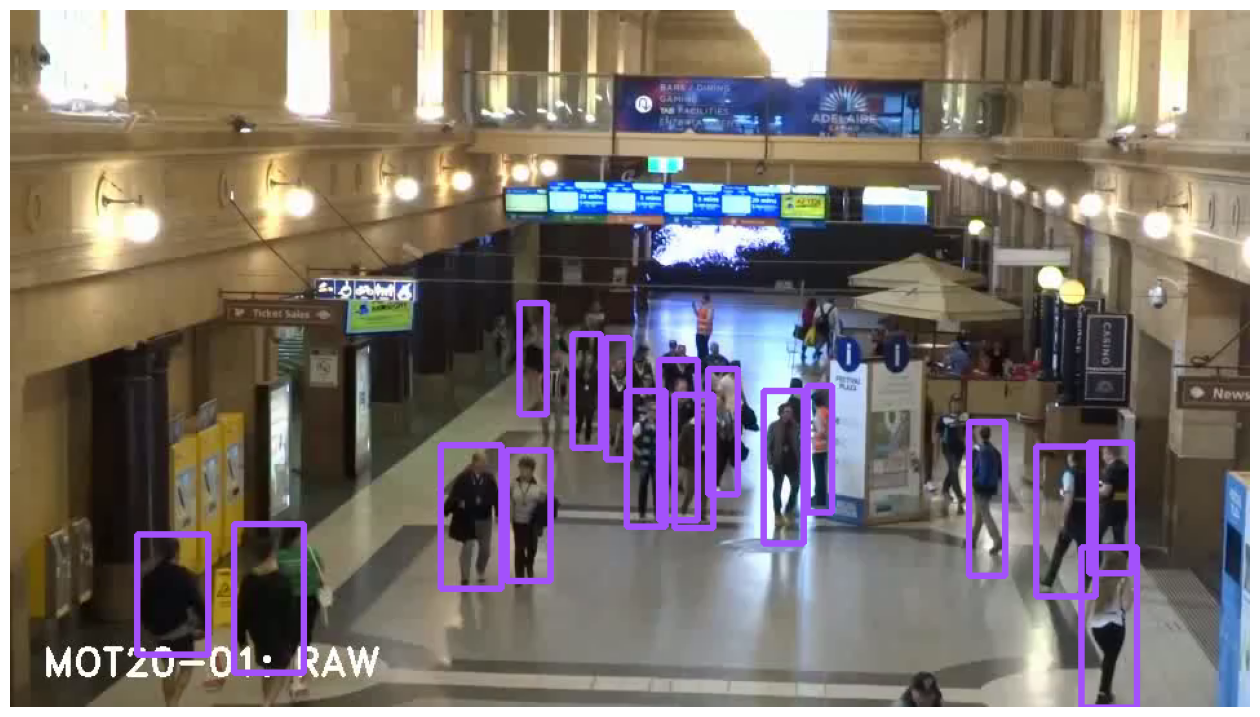

In [ ]:
import supervision as sv

# Specify the video path directly
video_path = "/content/drive/MyDrive/vid6.mp4"  # Replace with the actual path to your video

# Create the video frames generator
generator = sv.get_video_frames_generator(video_path)

# Create an iterator and get the first frame
iterator = iter(generator)
frame = next(iterator)

# Perform inference on the first frame
results = model(frame, imgsz=1280)[0]
detections = sv.Detections.from_ultralytics(results)

# Annotate only bounding boxes (skip label annotation)
box_annotator = sv.BoundingBoxAnnotator(thickness=4)
frame = box_annotator.annotate(scene=frame, detections=detections)

# Display the annotated frame
%matplotlib inline
sv.plot_image(frame, (16, 16))


0: 736x1280 16 persons, 28.0ms
Speed: 10.0ms preprocess, 28.0ms inference, 1.9ms postprocess per image at shape (1, 3, 736, 1280)


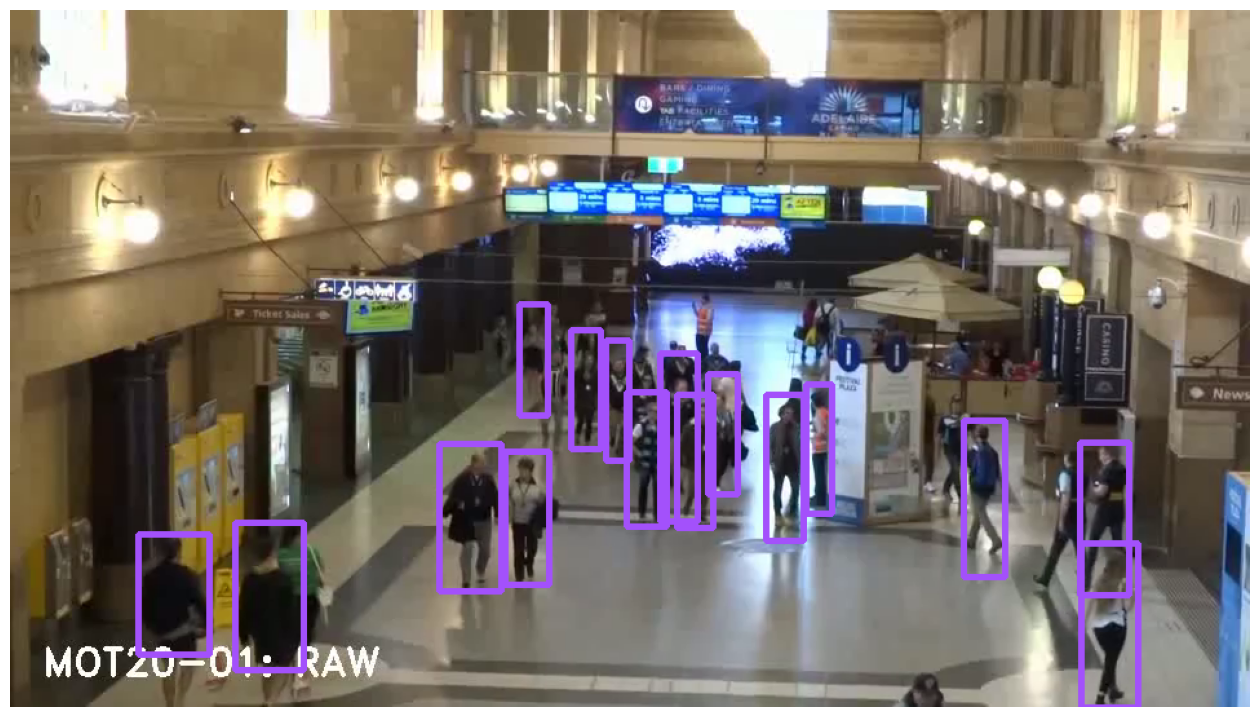

In [ ]:
# Get the next frame
frame2 = next(iterator)

# Perform inference on the second frame
results2 = model(frame2, imgsz=1280)[0]
detections2 = sv.Detections.from_ultralytics(results2)

# Annotate only bounding boxes for the second frame
frame2 = box_annotator.annotate(scene=frame2, detections=detections2)

# Display the second annotated frame
sv.plot_image(frame2, (16, 16))